In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

In [3]:
url = "https://raw.githubusercontent.com/royhridoy965-sketch/AI-and-ML-Lab/main/knn/Iris.csv"

df = pd.read_csv(url)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

In [8]:
X = df.drop(['Species','Id'], axis=1)

y = df['Species']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [10]:
cart = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

param_grid = {
    'max_depth':[2,3,4,5,6,None],
    'min_samples_split':[2,5,10]
}

cart_grid = GridSearchCV(
    cart,
    param_grid,
    cv=5,
    scoring='accuracy'
)

cart_grid.fit(X_train,y_train)

best_cart = cart_grid.best_estimator_

print(cart_grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [11]:
id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

id3_grid = GridSearchCV(
    id3,
    param_grid,
    cv=5,
    scoring='accuracy'
)

id3_grid.fit(X_train,y_train)

best_id3 = id3_grid.best_estimator_

print(id3_grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [12]:
cart_pred = best_cart.predict(X_test)

id3_pred = best_id3.predict(X_test)

In [13]:
cart_accuracy = accuracy_score(y_test,cart_pred)
cart_precision = precision_score(y_test,cart_pred,average='weighted')
cart_recall = recall_score(y_test,cart_pred,average='weighted')
cart_f1 = f1_score(y_test,cart_pred,average='weighted')

id3_accuracy = accuracy_score(y_test,id3_pred)
id3_precision = precision_score(y_test,id3_pred,average='weighted')
id3_recall = recall_score(y_test,id3_pred,average='weighted')
id3_f1 = f1_score(y_test,id3_pred,average='weighted')

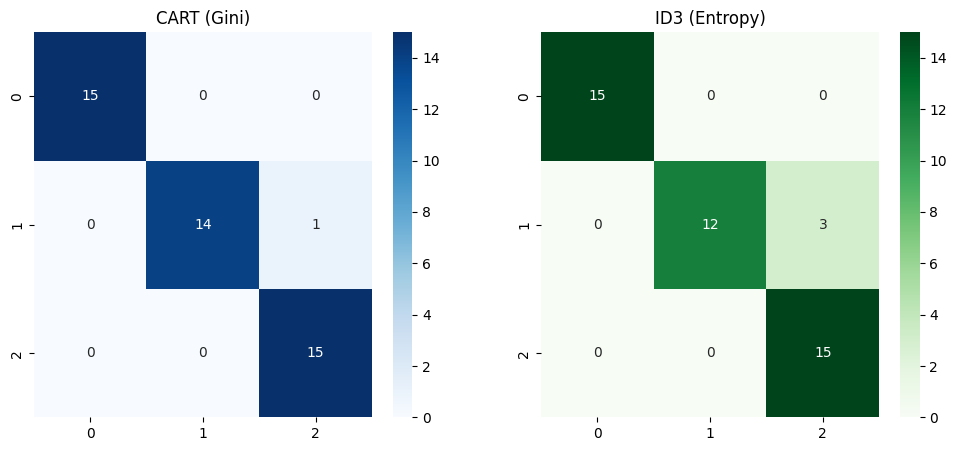

In [14]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test,cart_pred),
    annot=True,
    cmap='Blues',
    fmt='d',
    ax=ax[0]
)

ax[0].set_title("CART (Gini)")

sns.heatmap(
    confusion_matrix(y_test,id3_pred),
    annot=True,
    cmap='Greens',
    fmt='d',
    ax=ax[1]
)

ax[1].set_title("ID3 (Entropy)")

plt.show()

In [15]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

cart_prob = best_cart.predict_proba(X_test)

id3_prob = best_id3.predict_proba(X_test)

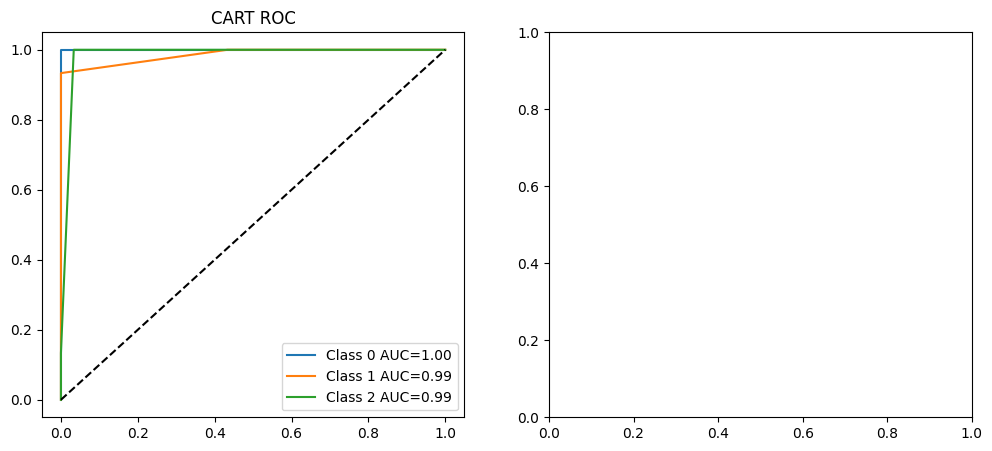

In [16]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

for i in range(3):
    fpr,tpr,_ = roc_curve(y_test_bin[:,i], cart_prob[:,i])
    roc_auc = auc(fpr,tpr)

    ax[0].plot(fpr,tpr,label=f'Class {i} AUC={roc_auc:.2f}')

ax[0].plot([0,1],[0,1],'k--')
ax[0].set_title("CART ROC")
ax[0].legend()

In [17]:
for i in range(3):
    fpr,tpr,_ = roc_curve(y_test_bin[:,i], id3_prob[:,i])
    roc_auc = auc(fpr,tpr)

    ax[1].plot(fpr,tpr,label=f'Class {i} AUC={roc_auc:.2f}')

ax[1].plot([0,1],[0,1],'k--')
ax[1].set_title("ID3 ROC")
ax[1].legend()

plt.show()

In [18]:
cart_auc = roc_auc_score(
    y_test_bin,
    cart_prob,
    multi_class='ovr'
)

id3_auc = roc_auc_score(
    y_test_bin,
    id3_prob,
    multi_class='ovr'
)

In [19]:
metrics = ['Accuracy','Precision','Recall','F1','AUC']

cart_values = [
    cart_accuracy,
    cart_precision,
    cart_recall,
    cart_f1,
    cart_auc
]

id3_values = [
    id3_accuracy,
    id3_precision,
    id3_recall,
    id3_f1,
    id3_auc
]

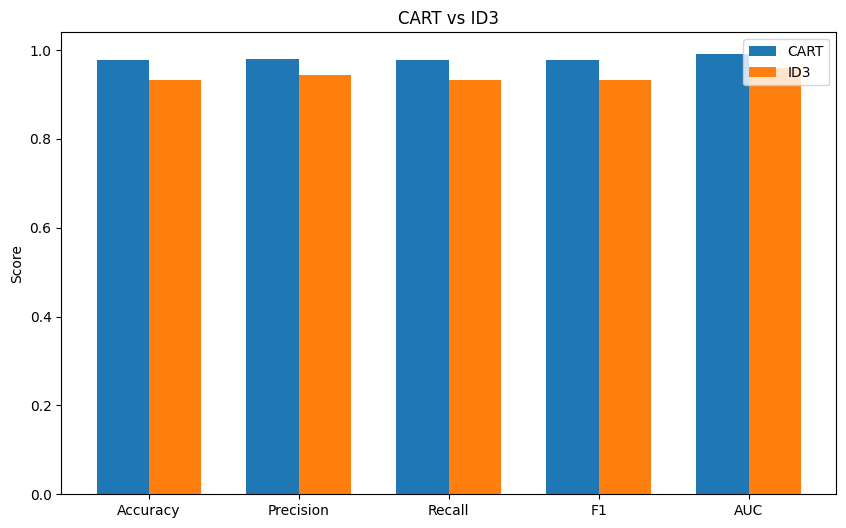

In [20]:
x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x-width/2,
    cart_values,
    width,
    label='CART'
)

plt.bar(
    x+width/2,
    id3_values,
    width,
    label='ID3'
)

plt.xticks(x,metrics)

plt.ylabel("Score")

plt.title("CART vs ID3")

plt.legend()

plt.show()

In [21]:
X2 = df[['SepalLengthCm','SepalWidthCm']]
y2 = df['Species']

In [22]:
X_train2,X_test2,y_train2,y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=42
)

In [23]:
cart_db = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3
)

id3_db = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

cart_db.fit(X_train2,y_train2)
id3_db.fit(X_train2,y_train2)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [24]:
x_min, x_max = X2.iloc[:,0].min()-1, X2.iloc[:,0].max()+1
y_min, y_max = X2.iloc[:,1].min()-1, X2.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'CART Boundary')

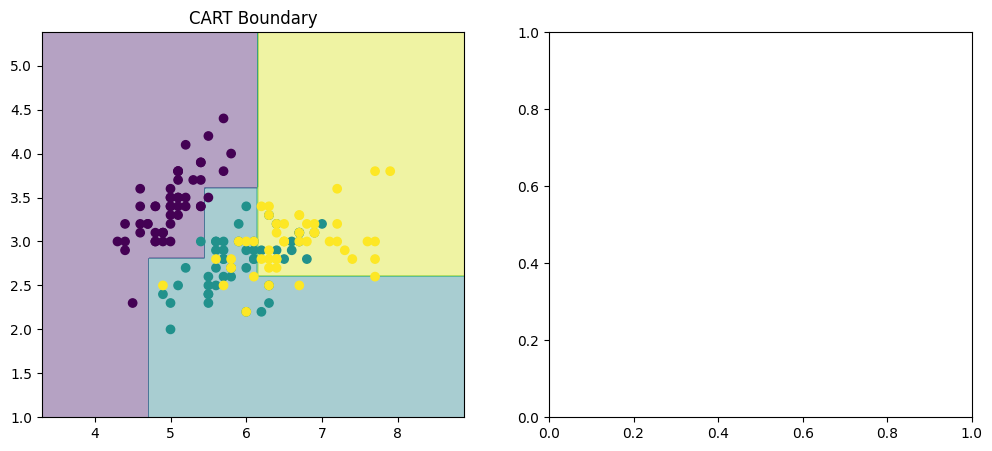

In [25]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

Z = cart_db.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

ax[0].contourf(xx,yy,Z,alpha=0.4)

ax[0].scatter(
    X2.iloc[:,0],
    X2.iloc[:,1],
    c=y2
)

ax[0].set_title("CART Boundary")

In [26]:
Z = id3_db.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

ax[1].contourf(xx,yy,Z,alpha=0.4)

ax[1].scatter(
    X2.iloc[:,0],
    X2.iloc[:,1],
    c=y2
)

ax[1].set_title("ID3 Boundary")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


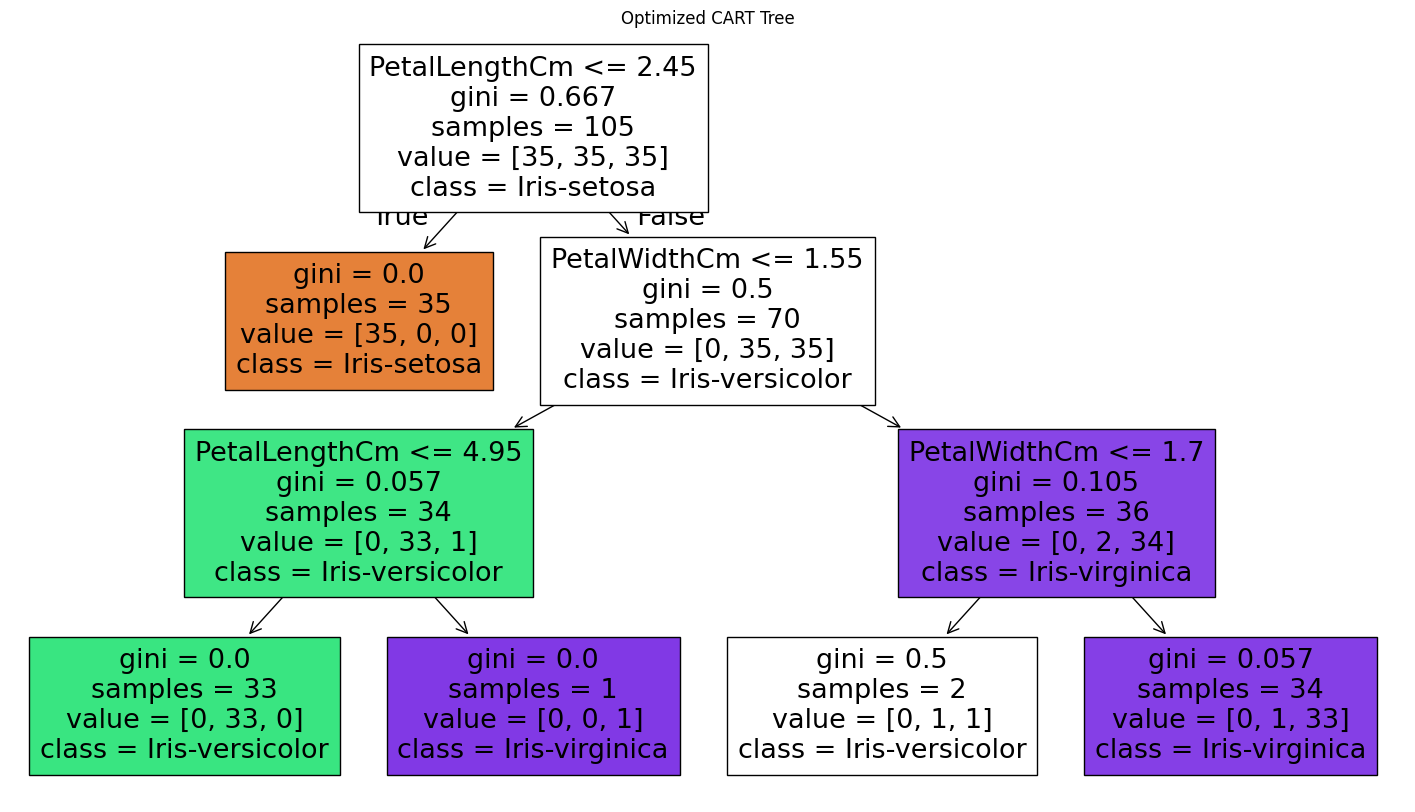

In [27]:
plt.figure(figsize=(18,10))

plot_tree(
    best_cart,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True
)

plt.title("Optimized CART Tree")

plt.show()

In [28]:
print("===== CART =====")
print("Accuracy :",cart_accuracy)
print("Precision :",cart_precision)
print("Recall :",cart_recall)
print("F1 :",cart_f1)
print("AUC :",cart_auc)

print()

print("===== ID3 =====")
print("Accuracy :",id3_accuracy)
print("Precision :",id3_precision)
print("Recall :",id3_recall)
print("F1 :",id3_f1)
print("AUC :",id3_auc)

===== CART =====
Accuracy : 0.9777777777777777
Precision : 0.9791666666666666
Recall : 0.9777777777777777
F1 : 0.9777530589543938
AUC : 0.9903703703703703

===== ID3 =====
Accuracy : 0.9333333333333333
Precision : 0.9444444444444444
Recall : 0.9333333333333333
F1 : 0.9326599326599326
AUC : 0.96
